<a href="https://colab.research.google.com/github/leenAbdulaziz-glitch/Recommendation-Scoring-Model/blob/main/Amazon_Product_Reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Amazon Product Reviews - Recommendation Scoring Model**

## Deep Learning Final Project
---
## About Dataset :

This dataset consists of reviews of fine foods from amazon. The data span a period of more than 10 years, including all ~500,000 reviews up to October 2012. Reviews include product and user information, ratings, and a plain text review. It also includes reviews from all other Amazon categories.

## Source :
**Kaggle** : [Amazon Product Reviews](https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews)

---

##**Pipeline:**
1. Data Loading & Exploration
2. Data Cleaning & Preprocessing
3. Feature Engineering
4. ANN Model with Regularization
5. Hyperparameter Tuning (Keras Tuner)
6. Evaluation & Metrics
7. Model Saving & Loading

---

#Libarary :



In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 1.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, re, string

warnings.filterwarnings('ignore')
np.random.seed(42)

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import load_model

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             r2_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

# Keras Tuner
import keras_tuner as kt
print("TensorFlow version:", tf.__version__)



TensorFlow version: 2.19.0


#1. Data preprocessing :



In [ ]:
df = pd.read_csv("Reviews.csv")

print(f"Shape: {df.shape}")
df.head()

Shape: (98053, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1.0,1.0,5.0,1.303862e+09,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0.0,0.0,1.0,1.346976e+09,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1.0,1.0,4.0,1.219018e+09,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3.0,3.0,2.0,1.307923e+09,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0.0,0.0,5.0,1.350778e+09,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:
print("Columns:", df.columns.tolist())

Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98053 entries, 0 to 98052
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Id                      98053 non-null  int64  
 1   ProductId               98053 non-null  object 
 2   UserId                  98053 non-null  object 
 3   ProfileName             98047 non-null  object 
 4   HelpfulnessNumerator    98052 non-null  float64
 5   HelpfulnessDenominator  98052 non-null  float64
 6   Score                   98052 non-null  float64
 7   Time                    98052 non-null  float64
 8   Summary                 98050 non-null  object 
 9   Text                    98052 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 7.5+ MB


In [ ]:
#Before Cleaning

print(f"Rows: {len(df)}")
print(f"Duplicates: {df.duplicated(subset=['UserId','ProductId','Text']).sum()}")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)


missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('_' * 45)
print('  df_results - MISSING VALUES REPORT')
print('_' * 45)
print(missing_df.to_string())
print(f'\n Total columns with missing data: {len(missing_df)}')


Rows: 98053
Duplicates: 216
_____________________________________________
  df_results - MISSING VALUES REPORT
_____________________________________________
                        Missing Count  Missing %
ProfileName                         6       0.01
HelpfulnessNumerator                1       0.00
HelpfulnessDenominator              1       0.00
Score                               1       0.00
Time                                1       0.00
Summary                             3       0.00
Text                                1       0.00

 Total columns with missing data: 7


In [ ]:
#Step 1: Drop duplicates (same user reviewed same product twice)
df = df.drop_duplicates(subset=['UserId', 'ProductId', 'Text'])

# Step 2: Drop rows with missing critical fields
df = df.dropna(subset=['Score', 'Text', 'UserId', 'ProductId'])

# Step 3: Fix impossible helpfulness (HelpfulnessNumerator > Denominator)
mask_bad = df['HelpfulnessNumerator'] > df['HelpfulnessDenominator']
df.loc[mask_bad, 'HelpfulnessNumerator'] = df.loc[mask_bad, 'HelpfulnessDenominator']

# Step 4: Remove reviews with 0-length text
df = df[df['Text'].str.strip().str.len() > 0]

# Step 5: Convert Score to int
df['Score'] = df['Score'].astype(int)

print("** AFTER CLEANING **")
print(f"Rows: {len(df)}")
print(f"Remaining missing values:\n{df[['Score','HelpfulnessDenominator','HelpfulnessNumerator']].isnull().sum()}")
df.describe()


** AFTER CLEANING **
Rows: 97836
Remaining missing values:
Score                     0
HelpfulnessDenominator    0
HelpfulnessNumerator      0
dtype: int64


,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,97836.000000,97836.000000,97836.000000,97836.000000,9.783600e+04
mean,49016.291692,1.630606,2.106587,4.150885,1.296368e+09
std,28299.100703,6.271723,6.878374,1.320004,4.772241e+07
min,1.000000,0.000000,0.000000,1.000000,9.486720e+08
25%,24514.750000,0.000000,0.000000,4.000000,1.270771e+09
50%,49018.500000,0.000000,1.000000,5.000000,1.311811e+09
75%,73521.250000,2.000000,2.000000,5.000000,1.332806e+09
max,98052.000000,559.000000,562.000000,5.000000,1.351210e+09


# Feature Engineering :

In [ ]:

#Text-based features
df['text_len']         = df['Text'].str.len()
df['word_count']       = df['Text'].str.split().str.len()
df['summary_len']      = df['Summary'].fillna('').str.len()
df['exclamation_count']= df['Text'].str.count('!')
df['question_count']   = df['Text'].str.count('\?')
df['upper_ratio']      = df['Text'].apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x)+1))

#Helpfulness ratio
df['helpfulness_ratio'] = (
    df['HelpfulnessNumerator'] /
    df['HelpfulnessDenominator'].replace(0, 1)   # avoid divide-by-zero
)

# Time feature (Unix timestamp > year/month)
df['review_date'] = pd.to_datetime(df['Time'], unit='s', errors='coerce')
df['review_year']  = df['review_date'].dt.year
df['review_month'] = df['review_date'].dt.month

#User & product activity (popularity proxy)
df['user_review_count']    = df.groupby('UserId')['Id'].transform('count')
df['product_review_count'] = df.groupby('ProductId')['Id'].transform('count')
df['user_avg_score']       = df.groupby('UserId')['Score'].transform('mean')
df['product_avg_score']    = df.groupby('ProductId')['Score'].transform('mean')

# TARGET: Binary - did user rate product ≥ 4 ?
df['liked'] = (df['Score'] >= 4).astype(int)

print("Class balance:")
print(df['liked'].value_counts())
print(f"\nPositive rate: {df['liked'].mean():.2%}")
print("\nSample features:")
df[['text_len','word_count','helpfulness_ratio','user_review_count',
    'product_review_count','user_avg_score','product_avg_score','liked']].head()

Class balance:
liked
1    75324
0    22512
Name: count, dtype: int64

Positive rate: 76.99%

Sample features:


,text_len,word_count,helpfulness_ratio,user_review_count,product_review_count,user_avg_score,product_avg_score,liked
0,263,48,1.0,1,1,5.0,5.00,1
1,190,31,0.0,1,1,1.0,1.00,0
2,509,94,1.0,1,1,4.0,4.00,1
3,219,41,1.0,1,1,2.0,2.00,0
4,140,27,0.0,1,4,5.0,4.75,1


#Train / Validation / Test Split & Scaling

In [ ]:
FEATURE_COLS = [
    'text_len', 'word_count', 'summary_len',
    'exclamation_count', 'question_count', 'upper_ratio',
    'helpfulness_ratio',
    'review_year', 'review_month',
    'user_review_count', 'product_review_count',
    'user_avg_score', 'product_avg_score'
]

TARGET = 'liked'

# Drop rows where features are NaN (e.g. review_date parse failures)
data = df[FEATURE_COLS + [TARGET]].dropna()

X = data[FEATURE_COLS].values
y = data[TARGET].values

print(f"Dataset size: {X.shape[0]:,} samples | {X.shape[1]} features")

# Split 70 / 15 / 15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape[0]:,} | Val: {X_val.shape[0]:,} | Test: {X_test.shape[0]:,}")

#Standard Scaling for the ANN
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print("Scaling done ")


Dataset size: 97,836 samples | 13 features
Train: 68,485 | Val: 14,675 | Test: 14,676
Scaling done 


#ANN Model with Regularization

In [ ]:
#ANN for binary recommendation scoring
#The model learn from the feature and pred if the user will love the prudect(1) or not (0)


#Architecture:
#3 hidden layers: 128 > 64 > 32 neurons
#Regularization techniques used:
#L2 (weight decay) to prevent large weights
#Dropout to reduce overfitting
#Batch Normalization to stabilize and speed up training

#Output layer uses Sigmoid for binary classification


def build_ann(input_dim,
              units_1=128, units_2=64, units_3=32,
              dropout_rate=0.3, l2_lambda=0.001,
              learning_rate=0.001):

    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),#each row receives input_dim features : text_len, word_count, helpfulness_ratio, ...

        # Block 1
        #Fully connected layer with 128 neurons
        #L2 regularization penalizes large weights (helps reduce overfitting)
        layers.Dense(units_1,
                     kernel_regularizer=regularizers.l2(l2_lambda),
                     kernel_initializer='he_normal'),
        #Normalizes activations > improves training stability
        layers.BatchNormalization(),
        #ReLU activation: introduces non-linearity
        #ReLU(x) = max(0, x)
        layers.Activation('relu'),
        #Randomly drops 30% of neurons during training
        #Prevents the model from relying too much on specific neurons
        layers.Dropout(dropout_rate),

        #Block 2
        #Second dense layer (64 neurons) > learns deeper patterns
        layers.Dense(units_2,
                     kernel_regularizer=regularizers.l2(l2_lambda),
                     kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(dropout_rate),

        #Block 3
        # Third dense layer (32 neurons) > compresses learned representation
        layers.Dense(units_3,
                     kernel_regularizer=regularizers.l2(l2_lambda),
                     kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        #Lower dropout here (more stable features at deeper level)
        layers.Dropout(dropout_rate / 2),

        #Output
        #Single neuron with Sigmoid activation
        #Outputs probability between 0 and 1
        #Example:
        #0.9 > likely positive (Liked)
        #0.1 > likely negative (Not liked)

        layers.Dense(1, activation='sigmoid')
    ], name="ANN_Recommendation_Scorer")

    #Model Compilation
    model.compile(
        #Adam optimizer: adaptive learning rate, fast and stable
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        #Binary Crossentropy:
        #Used for binary classification (0 or 1)
        loss='binary_crossentropy',
        #Evaluation metrics:
        metrics=['accuracy', # Overall correctness
                 keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )
    return model
#Build model using number of features from training data
model = build_ann(input_dim=X_train.shape[1])
#Print model architecture summary
model.summary()

Model: "ANN_Recommendation_Scorer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 12,609 (49.25 KB)

 Non-trainable params: 448 (1.75 KB)

#Training with Early Stopping & LR Scheduler

In [ ]:
#Callbacks أوامر تشتغل أثناء التدريب عشان تتحكم فيه

#EarlyStopping:
#Stops training if validation AUC does not improve for 10 epochs
#Prevents overfitting and saves training time
#Restores the best model weights instead of the last ones

early_stop = EarlyStopping(
    monitor='val_auc', mode='max',
    patience=10, restore_best_weights=True, verbose=1
)

#ReduceLROnPlateau:
#Reduces learning rate when validation loss stops improving
#Helps the model converge better and avoid oscillations
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=5, min_lr=1e-6, verbose=1
)
#Saves the best model based on validation AUC
checkpoint = ModelCheckpoint(
    'best_model.keras', monitor='val_auc',
    mode='max', save_best_only=True, verbose=1
)

#Train
#Train the model on training data and validate on validation set
#epochs=100 > maximum training iterations
#batch_size=512 > number of samples per gradient update
#callbacks > control training behavior (early stop, LR reduction, saving best model)
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=512,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)
print("\nTraining complete ")

Epoch 1/100
133/134 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7974 - auc: 0.8712 - loss: 0.8724 - precision: 0.9246 - recall: 0.7991
Epoch 1: val_auc improved from None to 0.98271, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
134/134 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.8836 - auc: 0.9396 - loss: 0.7055 - precision: 0.9438 - recall: 0.9025 - val_accuracy: 0.9406 - val_auc: 0.9827 - val_loss: 0.5285 - val_precision: 0.9697 - val_recall: 0.9526 - learning_rate: 0.0010
Epoch 2/100
132/134 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9408 - auc: 0.9756 - loss: 0.4828 - precision: 0.9535 - recall: 0.9707
Epoch 2: val_auc improved from 0.98271 to 0.98477, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9418 - auc: 0.9767 - loss: 0.4485 - precision: 0.9535 - recall: 0.9718 - val_accuracy: 0.9485 - val_auc: 0.9848 - val_loss: 0.3703 - val_prec

#Training History

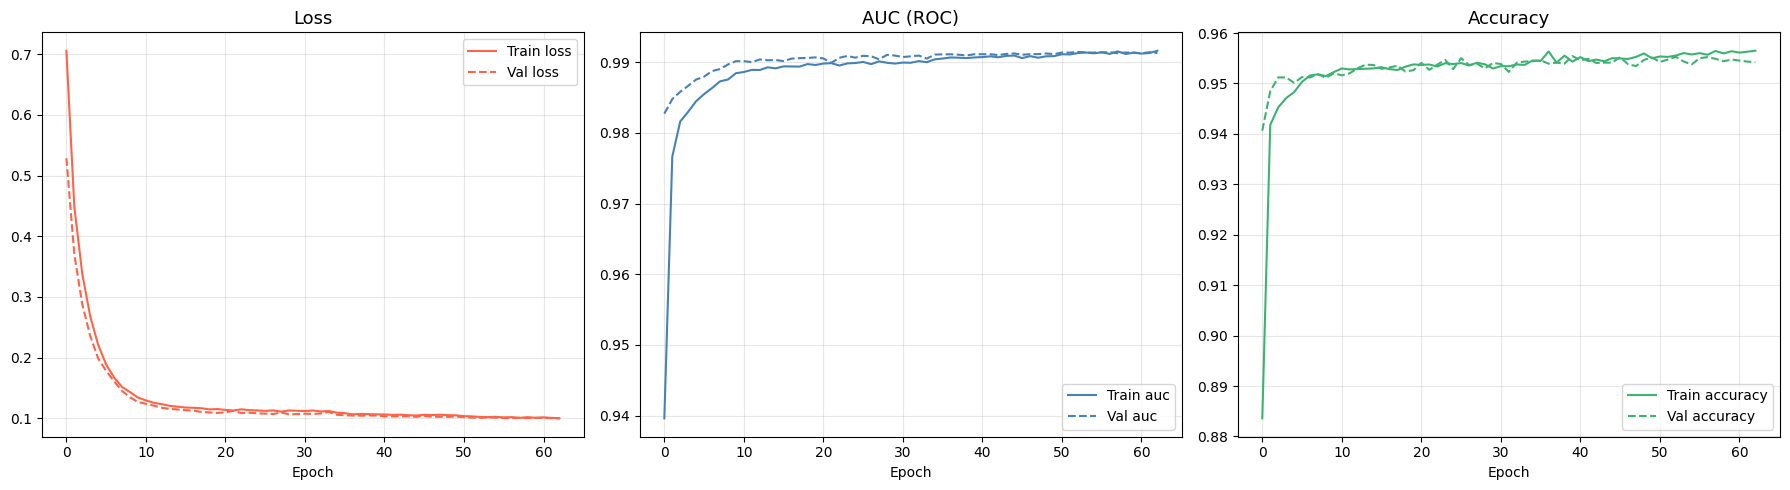

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def plot_metric(ax, history, metric, title, color='steelblue'):
    ax.plot(history.history[metric], label=f'Train {metric}', color=color)
    ax.plot(history.history[f'val_{metric}'], label=f'Val {metric}',
            color=color, linestyle='--')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plot_metric(axes[0], history, 'loss',     'Loss',             'tomato')
plot_metric(axes[1], history, 'auc',      'AUC (ROC)',        'steelblue')
plot_metric(axes[2], history, 'accuracy', 'Accuracy',         'mediumseagreen')

plt.tight_layout()
plt.savefig("training_history.png", dpi=120)
plt.show()

#Hyperparameter Tuning with Keras Tuner

In [ ]:
# 1Define the Model Builder Function

def build_tunable_model(hp):

    #Choose number of neurons for the 1st layer (between 64 and 256)
    units_1 = hp.Int('units_1',   min_value=64,  max_value=256, step=64)

    #Choose number of neurons for the 2nd layer (between 32 and 128)
    units_2 = hp.Int('units_2',   min_value=32,  max_value=128, step=32)

    #Choose number of neurons for the 3rd layer (between 16 and 64)
    units_3 = hp.Int('units_3',   min_value=16,  max_value=64,  step=16)

    #Choose a Dropout rate to prevent the model from "memorizing" (Overfitting)
    dropout  = hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)

    #Pick a value for L2 Regularization (helps keep weights small/stable)
    l2_val   = hp.Choice('l2',    values=[0.0001, 0.001, 0.01])

    #Pick the best Learning Rate (how fast the model learns)
    lr       = hp.Choice('lr',    values=[0.0001, 0.001, 0.01])

    #Send these choices to our main ANN function to build the model
    return build_ann(
        input_dim=X_train.shape[1],
        units_1=units_1, units_2=units_2, units_3=units_3,
        dropout_rate=dropout, l2_lambda=l2_val, learning_rate=lr
    )


#Setup the Search Engine (The Tuner)

tuner = kt.RandomSearch(
    build_tunable_model,           # Use the function we just created
    objective=kt.Objective('val_auc', direction='max'), # Goal: Get the highest AUC score
    max_trials=10,                 # Try 10 different random combinations
    executions_per_trial=1,        # Train each combination 1 time
    directory='kt_results',        # Folder to save the results
    project_name='recommendation_scorer',
    overwrite=True                 # Clear old results before starting
)


# 3. Start the Searching Process

tuner.search(
    X_train, y_train,              # Training data
    validation_data=(X_val, y_val),# Data used to check if the model is good
    epochs=30,                     # Number of training rounds for each trial
    batch_size=512,
    # Stop early if the model stops improving to save time
    callbacks=[EarlyStopping(monitor='val_auc', mode='max', patience=5)],
    verbose=0                      # Keep the output clean (don't show every step)
)


#Get and Print the Best Results

#Get the best settings found during the 10 trials
best_hp = tuner.get_best_hyperparameters(1)[0]

print("\n Best Hyperparameters Found:")
#Loop through the best settings and print them
for k, v in best_hp.values.items():
    print(f"  {k}: {v}")



 Best Hyperparameters Found:
  units_1: 256
  units_2: 96
  units_3: 64
  dropout: 0.2
  l2: 0.001
  lr: 0.001


In [ ]:
#Retrieve the Winning Model

#We ask the tuner to give us the #1 best model it found during the search
best_model = tuner.get_best_models(num_models=1)[0]


# 2. Final Training (The "Main Event")
history_best = best_model.fit(
    X_train, y_train,           # Training with our full training dataset
    validation_data=(X_val, y_val), # Checking performance on validation data
    epochs=100,                 # Give it more time (100 rounds) to reach maximum accuracy
    batch_size=512,             # Process 512 rows at a time

    # Callbacks are "smart" features that watch the training:
    callbacks=[
        # EarlyStopping: If the score (AUC) doesn't improve for 10 rounds, stop training.
        # 'restore_best_weights=True' ensures we keep the best version, not the last one.
        EarlyStopping(monitor='val_auc', mode='max', patience=10,
                      restore_best_weights=True),

        # ReduceLROnPlateau: If the model gets "stuck", cut the learning rate in half (factor=0.5).
        # This helps the model "fine-tune" its way to the best result.
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    ],
    verbose=1 # Show the progress bar so we can see the training happening
)

print("\nBest model re-trained successfully!")


Epoch 1/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9537 - auc: 0.9900 - loss: 0.1133 - precision: 0.9642 - recall: 0.9761 - val_accuracy: 0.9538 - val_auc: 0.9907 - val_loss: 0.1097 - val_precision: 0.9585 - val_recall: 0.9826 - learning_rate: 0.0010
Epoch 2/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9546 - auc: 0.9902 - loss: 0.1127 - precision: 0.9652 - recall: 0.9763 - val_accuracy: 0.9539 - val_auc: 0.9906 - val_loss: 0.1103 - val_precision: 0.9571 - val_recall: 0.9842 - learning_rate: 0.0010
Epoch 3/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9556 - auc: 0.9905 - loss: 0.1104 - precision: 0.9646 - recall: 0.9783 - val_accuracy: 0.9528 - val_auc: 0.9906 - val_loss: 0.1095 - val_precision: 0.9619 - val_recall: 0.9773 - learning_rate: 0.0010
Epoch 4/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9544 - auc: 0.9904 - loss: 0.1114 - precision: 0.9653 - recall: 0.9758 - val_accuracy: 0.9528 - val_auc: 0.9903 - val_loss: 0.11

#Evaluation on Test Set

In [ ]:
# Choose the better of the two models
print("__ Baseline Model (Test) __")

#compure Baseline(النموذج الاساسي) and Tuned(المحسن)
baseline_results = model.evaluate(X_test, y_test, verbose=0)
for name, val in zip(model.metrics_names, baseline_results):
    print(f"  {name}: {val:.4f}")

print("\n__ Tuned Model (Test) __")
tuned_results = best_model.evaluate(X_test, y_test, verbose=0)
for name, val in zip(best_model.metrics_names, tuned_results):
    print(f"  {name}: {val:.4f}")

# Use tuned model for rest of evaluation
final_model = best_model

__ Baseline Model (Test) __
  loss: 0.1015
  compile_metrics: 0.9567

__ Tuned Model (Test) __
  loss: 0.1059
  compile_metrics: 0.9552


In [ ]:
# Predictions
y_prob = final_model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Liked (0)', 'Liked (1)']))




Classification Report:
               precision    recall  f1-score   support

Not Liked (0)       0.93      0.87      0.90      3377
    Liked (1)       0.96      0.98      0.97     11299

     accuracy                           0.96     14676
    macro avg       0.95      0.93      0.94     14676
 weighted avg       0.95      0.96      0.95     14676



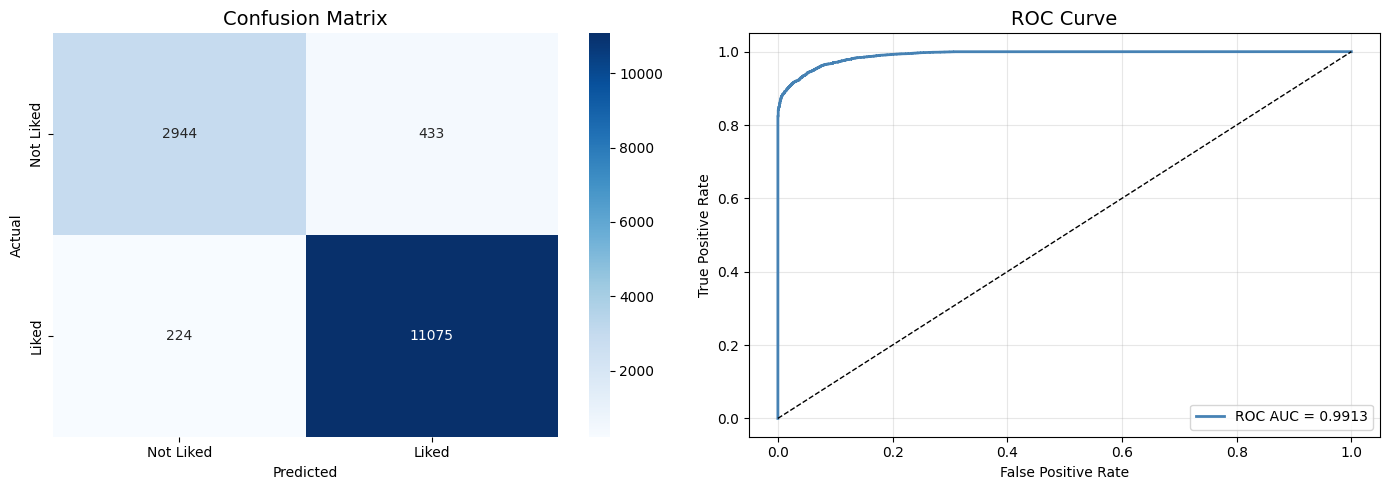

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Liked', 'Liked'],
            yticklabels=['Not Liked', 'Liked'])
axes[0].set_title('Confusion Matrix', fontsize=14)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'ROC AUC = {auc_score:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=14)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("evaluation_plots.png", dpi=120)
plt.show()

#Model Saving & Loading

In [ ]:
import pickle

# Save model
final_model.save("recommendation_scorer_final.keras")
print("Model saved >  recommendation_scorer_final.keras")

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("Scaler saved >  scaler.pkl")

# Save feature list
with open("feature_cols.pkl", "wb") as f:
    pickle.dump(FEATURE_COLS, f)
print("Feature columns saved ")

Model saved >  recommendation_scorer_final.keras
Scaler saved >  scaler.pkl
Feature columns saved 


In [ ]:
# Load model & verify
import pickle

loaded_model  = load_model("recommendation_scorer_final.keras")
with open("scaler.pkl", "rb") as f:
    loaded_scaler = pickle.load(f)

# Quick sanity check
loaded_preds = loaded_model.predict(X_test[:5], verbose=0).ravel()
orig_preds   = final_model.predict(X_test[:5], verbose=0).ravel()

print("Loaded model predictions:", np.round(loaded_preds, 6))
print("Original model predictions:", np.round(orig_preds, 6))
print("\nMatch:", np.allclose(loaded_preds, orig_preds, atol=1e-5))
print("\nModel loaded & verified ")

Loaded model predictions: [0.999785 0.999904 0.185421 0.999688 0.999909]
Original model predictions: [0.999785 0.999904 0.185421 0.999688 0.999909]

Match: True

Model loaded & verified 


#Inference - Predict for new review

In [ ]:
import numpy as np
import pandas as pd

#This function takes raw review data, processes it into features, and uses the trained model to predict if a user likes a product.
def predict_recommendation_score(
    review_text, summary, score, helpfulness_num,
    helpfulness_den, review_timestamp,
    user_review_count, product_review_count,
    user_avg_score, product_avg_score,
    model=None, scaler=None
):


    # Check if the model and scaler are provided
    if model is None or scaler is None:
        raise ValueError("Please provide both model and scaler!")

    #Feature Extraction (Text Features) ---
    text_len          = len(review_text)
    word_count        = len(review_text.split())
    summary_len       = len(summary)
    exclamation_count = review_text.count('!')
    question_count    = review_text.count('?')

    #Calculate ratio of uppercase letters (helps identify excitement/shouting)
    upper_ratio       = sum(1 for c in review_text if c.isupper()) / (len(review_text) + 1)

    #Calculate helpfulness ratio (using max to avoid division by zero)
    helpfulness_ratio = helpfulness_num / max(helpfulness_den, 1)

    #Date Processing
    #Convert Unix timestamp to a readable date format
    date = pd.to_datetime(review_timestamp, unit='s', errors='coerce')
    #Default to specific year/month if the date is invalid
    review_year  = date.year  if date is not pd.NaT else 2012
    review_month = date.month if date is not pd.NaT else 1

    #Feature Assembly
    # Combine all extracted features into a single 2D array (numpy matrix)
    features = np.array([[
        text_len, word_count, summary_len,
        exclamation_count, question_count, upper_ratio,
        helpfulness_ratio,
        review_year, review_month,
        user_review_count, product_review_count,
        user_avg_score, product_avg_score
    ]])

    #Scaling and Prediction
    #Important: Apply the same scaling transformation used during training
    features_scaled = scaler.transform(features)

    # Use the model to predict the probability (score between 0 and 1)
    prob = model.predict(features_scaled, verbose=0)[0][0]

    #Output Result
    # Determine the label based on a 0.5 threshold
    label = "LIKED" if prob >= 0.5 else "NOT LIKED"
    print(f"Recommendation Score: {prob:.4f}  →  {label}")

    return prob

#Example Usage
# Testing the function with a sample review
predict_recommendation_score(
    review_text="This product is absolutely amazing! Best purchase I ever made. Highly recommend to everyone!",
    summary="Amazing product!",
    helpfulness_num=10,
    helpfulness_den=12,
    review_timestamp=1320192000, # Example timestamp
    user_review_count=25,
    product_review_count=180,
    user_avg_score=4.2,
    product_avg_score=4.5,
    model=loaded_model,
    scaler=loaded_scaler
)

Recommendation Score: 0.9426  →  LIKED


np.float32(0.94262177)